In [ ]:
!pip install -i https://mirror-pypi.runflare.com/simple opencv-python

In [1]:
import tensorflow as tf
from tensorflow import keras

from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input, decode_predictions
# import keras.utils as image
from keras.optimizers import AdamW
from keras.losses import categorical_crossentropy

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def predict(image, model):
    x = np.array(image)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    pred = model.predict(x)
    class_pred = decode_predictions(pred, top=3)[0][0][1]

    return class_pred


In [ ]:
model = VGG16(weights="imagenet")
model.summary()

In [19]:
cap = cv2.VideoCapture(0)

In [21]:
is_success, fram = cap.read()

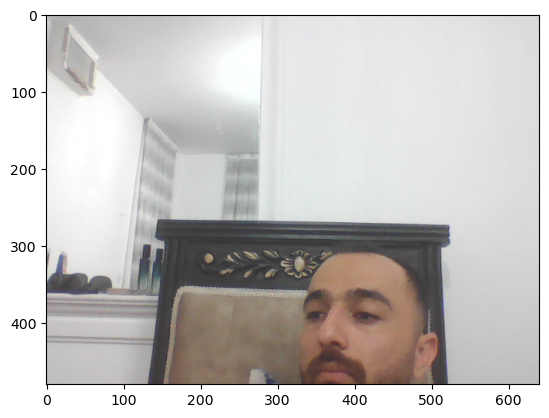

In [22]:
import matplotlib.pyplot as plt

plt.imshow(fram[..., ::-1])

In [ ]:
while True:
    is_success, fram = cap.read()
    fram = cv2.resize(fram, (224, 224))
    pred = predict(fram[..., ::-1], model)
    cv2.putText(fram, pred, (30, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    cv2.imshow("Real Time Video", fram)

    if cv2.waitKey(1) & 0xff == 27:
        break 
    
cv2.destroyAllWindows()
cap.release()